# LangGraph and Agentic Workflows

An agent acts on behalf of the principal. Therefore, an agent has behavior that can range from strictly rule-based to largely autonomous. We already interact with LLMs using prompts, known as prompt engineering. Prompt engineering is how humans interact with LLMs, and agentic workflows are how LLMs interoperate with tools and other agents, which we can call flow engineering.

References:

- A long article on Agents: https://huyenchip.com//2025/01/07/agents.html (you should definitely read this before you deep-dive into building an agentic workflow)

- What are AI Agents? https://aws.amazon.com/what-is/ai-agents/

In [1]:
from google.colab import drive
drive.mount('/content/drive')  # Add My Drive/<>

import os
os.chdir('drive/My Drive')
os.chdir('Books_Writings/NLPBook/')

Mounted at /content/drive


In [2]:
%%capture
# %pylab inline
import numpy as np
import pandas as pd
import os
!pip install Pillow<10.0.0
# !pip install --upgrade ipypublish --quiet
# from ipypublish import nb_setup
from IPython.display import Image, display

In [3]:
import textwrap

def p80(text):
    print(textwrap.fill(text, 80))
    return None

More recently AI agents can do [autonomous research](https://www.oneusefulthing.org/p/the-end-of-search-the-beginning-of). See OpenAI's [DeepResearch](https://openai.com/index/introducing-deep-research/) agent.  


## Why LangGraph?

1. LangChain defines DAGs and chains are a special case. But if you want to have cycles you need more than a chain. This is what LangGraph does. It is more than just a pipe.

2. LangGraph supports agents better. Agents tend to have tasks that require cycles as in the cognitive activity of reflection, for example. So agentic workflows critically rely on LangGraph.

3. LangChain is not set up as a state machine, whereas LangGraph is.

To quote from LangGraph:

"**Motivation**

One of the big value props of LangChain is the ability to easily create custom chains. We've invested heavily in the functionality for this with LangChain Expression Language. However, so far we've lacked a method for easily introducing cycles into these chains. Effectively, these chains are directed acyclic graphs (DAGs) - as are most data orchestration frameworks.

One of the common patterns we see when people are creating more complex LLM applications is the introduction of cycles into the runtime. These cycles often use the LLM to reason about what to do next in the cycle. A big unlock of LLMs is the ability to use them for these reasoning tasks. This can essentially be thought of as running an LLM in a for-loop. These types of systems are often called agents."

Read more here: https://blog.langchain.dev/langgraph/

## Agent Taxonomy

We can think of various kinds of agents, and a brief (and hardly unique) taxonomy is offered below.

1. Single task agents. These orchestrate a specific task behind the scenes based on instructions that can be simple or complex. For example, the /generate command in jupyter-ai produces a notebook for a specific task as specified in the jupyternaut chat prompt. Therefore, prompting asks an LLM to act as an agent to do a task, and the type of prompt may require simple or complex behavior from the LLM behind the scenes. For a collection of prompting approaches and related science artifacts, see Prompt Science.
2. Helper agents (Assistants). An example is Copilot Workspace, a generative development environment that’s designed to encompass entire projects. These are very general agents, that are ever present, and work with an IDE. What is interesting is that this is a Copilot-native developer environment. This line in their blog is poignant — “You retain all of the autonomy, while Copilot Workspace lifts your cognitive strain.”
    
3. Chained agents. These are agents that undertake a series of actions in sequence, for example LangChain agents. However, unlike single task agents that implement hard-coded steps, chained agents rely on a LLM to determine what steps to take, known as a chain of thought. We may invoke an agent to specifically take action in steps by simply adding “Let’s think step by step”, known as AutoCoT. Agents are of various types, which implement different concepts.

4. Stateful agents. These are agents that initiate actions dependent on state. A good example is jupyter-scheduler, which runs a notebook at a fixed time, which is the state it depends on. State may be multidimensional, of course. Any ChatGPT plugins that are state-dependent would fall in this category. Stateful agents are usually “live” in the sense that they do not terminate and wait for the activation state to occur.

5. Graph agents. A generalization of stateful agents, with a different implementation. Implementing an agent may be done more flexibly using a DAG instead of a sequential chain, with tools like LangGraph. Each node in the graph is a function that executes an action based on the state. Here conditional branching is possible. Cyclic LangGraphs are also implementable, not just DAGs. State is updated at each node and passed to the next one.  

## Agentic Workflows

Andrew Ng defines four agentic workflows: (i) Reflection, (ii) Tool use, (iii) Planning, and (iv) Multi-agent collaboration. See his [YouTube talk](https://www.youtube.com/watch?v=sal78ACtGTc&t=9s). These are described below using the ideas in the taxonomy above.

1. Reflection involves evaluating the response from an LLM, then refining the prompt to get a better answer. This can be done by an agent instead of a human.
2. Tool Use is behavior demonstrated by an agent that will autonomously use a tool (e.g., a search API to collect current information) in performing a task.
3. A Planning agent will take the original prompt and first establish the plan, i.e., the graph agent (in LangGraph, say) and then execute the graph.
4. Multi-agent collaborations are generalizations where there may be multiple graphs, one for each agent but state is passed between graphs, not just nodes on the same graph. And we may also think of a single graph with each node being an actor/agent.




## LangGraph for Agents

References:
- https://python.langchain.com/v0.1/docs/langgraph/
- https://github.com/langchain-ai/langgraph/tree/main/examples
- https://blog.langchain.dev/langgraph/

Agentic workflows are described as graphs. A simple sequential example is as follows, where an agent operates between the start and end nodes in a graph (this is the traditional langchain we are used to):


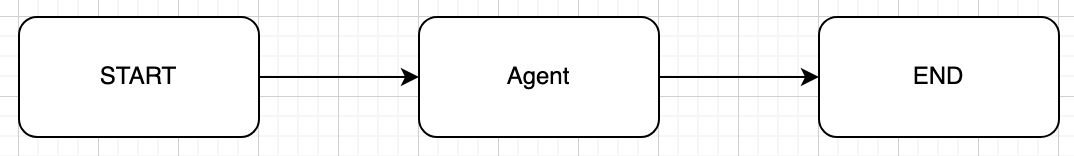

In [ ]:
# nb_setup.images_hconcat(['NLP_images/simple_agent.png'], width=800)
Image('NLP_images/simple_agent.png', width=800)

Agents operate autonomously in a complex ecosystem. An excellent exposition is provided by this graphic from a [talk](https://www.youtube.com/watch?v=pBBe1pk8hf4) by Harrison Chase. Here is the “Agent Diagram”.

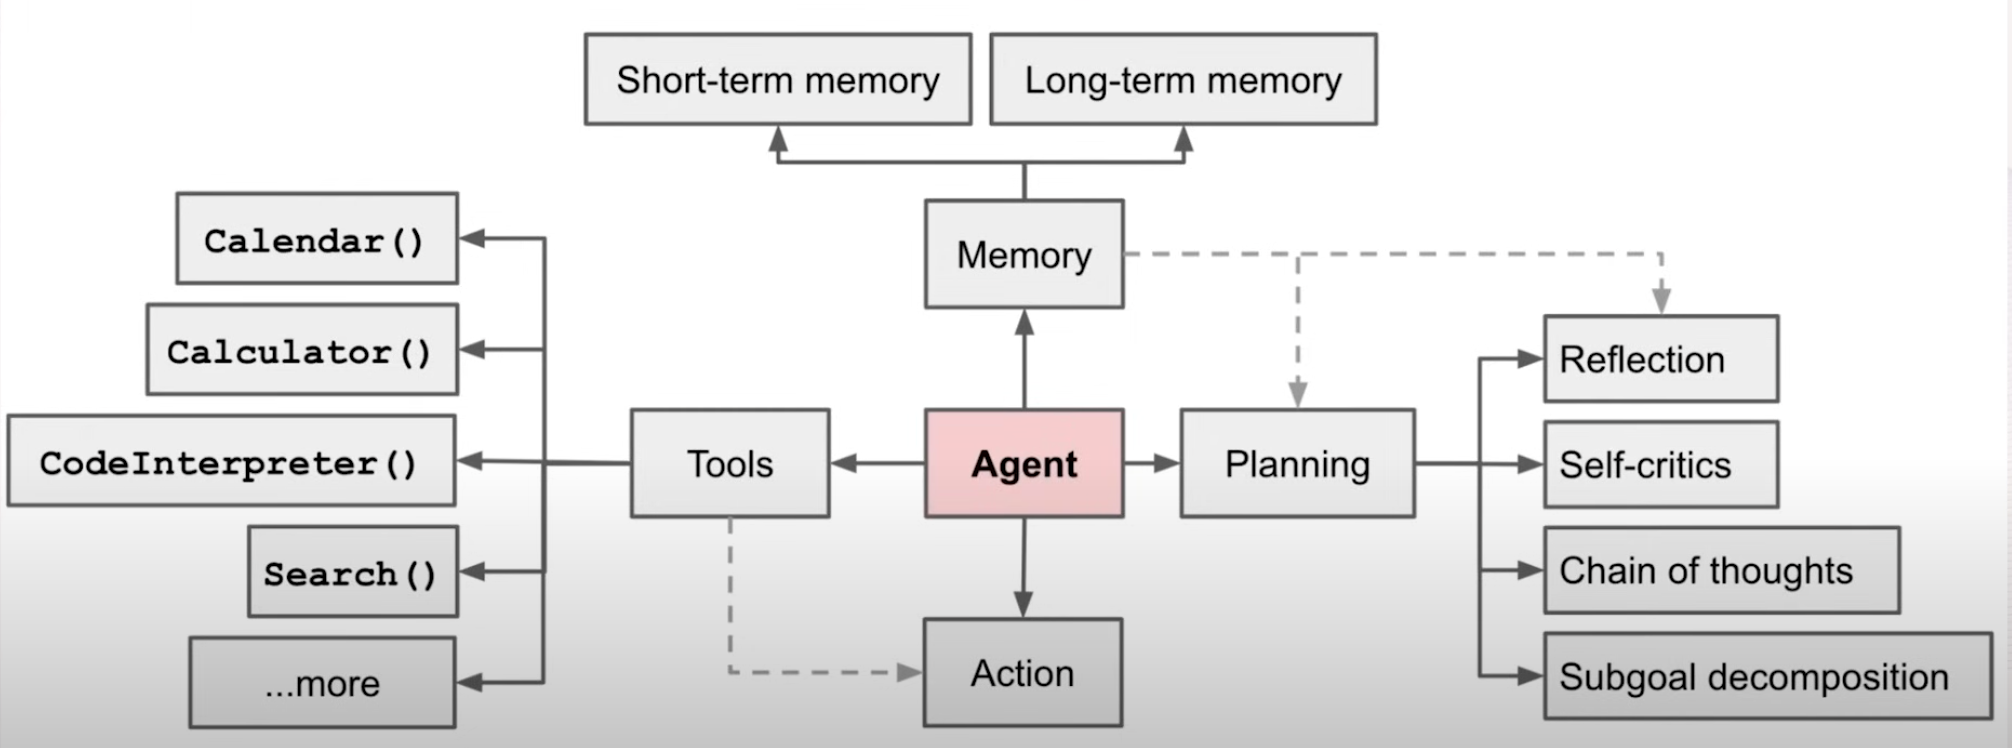

In [ ]:
Image('NLP_images/HarrisonChase_agent_diagram.png', width=800)

The Short-term memory above is the same as conversational memory in LLM prompting, and Long-term memory is using RAG. An agent interacts with tools, accesses contextual memory, makes plans, and takes actions. Planning comes before taking action (ex ante) and reflection comprises post-action review and further action (ex post).

## A Simple LangGraph

In [4]:
!pip install -U langchain --quiet
!pip install -U langgraph --quiet
!pip install -U langchain_openai --quiet
!pip install -U langchain_aws --quiet
!pip install -U langchain_community --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85

In [5]:
%run keys.ipynb

To create a `langgraph` add nodes and edges to an initial `MessageGraph` or `StateGraph`.

- `langgraph` chains nodes using a graph with edges.
- There has to be an entry node (START) and a END node.
- In the simplest langgraph, the entry node is connected to the end node by an edge.
- When a node is added with `add_node`, we give it a name and the supporting action Agent Executor, which could be a *model* or a *function*.
- We construct the graph by adding nodes and edges. The `add_edge` method adds an edge and takes the start node and end node as arguments.
- Think of the *state* of the agent as a list of messages.

There are two types of graphs:
1. `MessageGraph`: The State of a MessageGraph is ONLY a list of messages. This class is mostly used  for chatbots, as most applications require the State to be more complex than a list of messages. This is being deprecated.
2. `StateGraph`: The more common and general kind of graph used in LangGraph.

Reference: https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs


In [6]:
import os
from typing import TypedDict, Annotated, List
import operator
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# Set up OpenAI API key (replace with your actual key or environment variable)
# os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"

# Define the graph state
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

# Initialize the OpenAI LLM
llm = ChatOpenAI(model="gpt-4o")

# Define the entry node function
def entry_node(state: AgentState) -> AgentState:
    """Processes the initial user input."""
    print("---Entry Node: Processing initial input---")
    # In a real scenario, you might do some initial parsing or validation here
    return state

# Define the middle node function (using OpenAI LLM)
def llm_node(state: AgentState) -> AgentState:
    """Invokes the LLM to generate a response."""
    print("---Middle Node: Invoking LLM---")
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

# Define the end node function
def end_node(state: AgentState) -> AgentState:
    """Handles the final output of the graph."""
    print("---End Node: Finalizing response---")
    # In a real scenario, you might store the conversation or format the final output
    return state

# Build the LangGraph
workflow = StateGraph(AgentState)

# Add nodes to the workflow
workflow.add_node("entry_node", entry_node)
workflow.add_node("llm_node", llm_node)
workflow.add_node("end_node", end_node)

# Define edges (sequential flow)
workflow.add_edge(START, "entry_node")
workflow.add_edge("entry_node", "llm_node")
workflow.add_edge("llm_node", "end_node")
workflow.add_edge("end_node", END)

# Compile the graph
app = workflow.compile()

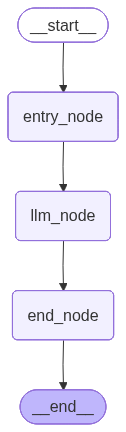

In [7]:
# Show the nodes and edges
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
# List nodes
for node in app.nodes:
    print(node)

__start__
entry_node
llm_node
end_node


In [9]:
# Run the graph
initial_message = "Tell me a fun fact about giraffes."
inputs = {"messages": [HumanMessage(content=initial_message)]}
final_state = app.invoke(inputs)

---Entry Node: Processing initial input---
---Middle Node: Invoking LLM---
---End Node: Finalizing response---


In [10]:
# Print the final output
print("\n---Final Output---")
p80(final_state["messages"][-1].content)


---Final Output---
A fun fact about giraffes is that they have incredibly long tongues, which can
measure up to 18 to 20 inches (45 to 50 centimeters) in length. This adaptation
allows them to reach and skillfully strip leaves from tall trees, particularly
acacias, which are their favorite food. Their tongues are also prehensile and a
dark bluish or purplish color, which may protect them from sunburn as they spend
a lot of time foraging high in the canopy.


**Summary:**

1. AgentState: A TypedDict defining the shared state of the graph, which in this case is a list of BaseMessage objects to represent the conversation history.
2. llm: An instance of ChatOpenAI is initialized, providing the large language model for the llm_node.
3. entry_node: This function serves as the starting point of the workflow. It receives the initial state and can perform any setup or preprocessing.
4. llm_node: This is the core middle node where the OpenAI LLM is invoked. It takes the current messages from the state, passes them to the LLM, and updates the state with the LLM's response.
5. end_node: This function marks the end of the workflow. It receives the final state and can be used for post-processing, logging, or formatting the output for the user.

**Graph Construction:**

1. StateGraph(AgentState) initializes the graph with the defined state.
2. add_node() registers each function as a node in the graph.
3. add_edge() defines the sequential flow, connecting the START point to entry_node, entry_node to llm_node, llm_node to end_node, and finally end_node to the END point of the graph.

**Execution:**

1. workflow.compile() compiles the graph into an executable application.
2. app.invoke() runs the graph with the given initial input, and the final_state contains the updated state after the entire workflow has executed.
3. The final message from the LLM is then printed.

## LangGraph with Tools and Routers

It’s best to show this with a demo implementation. A simple example is one where an agent can call itself multiple times based on a condition so that it cycles if necessary. The agent may also call a **tool** if needed. We have two tools below, *multiply* and *add*.

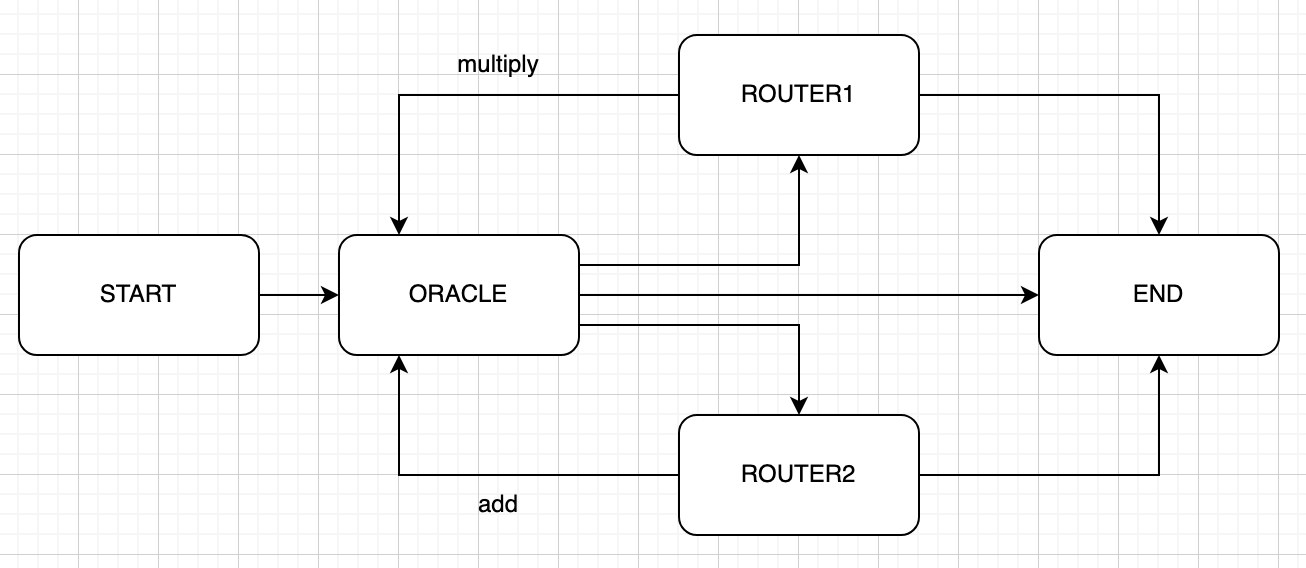

In [ ]:
Image('NLP_images/agent_diagram_example.png', width=800)

In this flow diagram, we can request the agent (Oracle) to answer questions. If any of these questions relate to addition or multiplication of numbers, then the LLM will use the predefined tool functions for add and multiply, which we will shown in the code below.

In [11]:
import operator
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START # Removed Node import

# 1. Define the Tools
@tool
def add(a: float, b: float) -> float:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiplies two numbers."""
    return a * b

tools = [add, multiply]

# 2. Define the Agent State
class AgentState(TypedDict):
    question: str
    result: Annotated[float, operator.add]
    intermediate_steps: Annotated[list, operator.add]

# 3. Define the Nodes
def entry_node(state: AgentState) -> AgentState:
    """Initializes the graph with the user's question."""
    print("---ENTRY NODE---")
    return {"question": state["question"], "result": 0.0, "intermediate_steps": []}

def tool_use_node(state: AgentState) -> AgentState:
    """Uses the OpenAI model to determine which tool to use and executes it."""
    print("---TOOL USE NODE---")
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    llm_with_tools = llm.bind_tools(tools)

    response = llm_with_tools.invoke(state["question"])

    tool_calls = response.tool_calls
    if not tool_calls:
        return {"intermediate_steps": state["intermediate_steps"] + [f"No tool calls found for: {state['question']}"]}

    tool_output = None
    for tool_call in tool_calls:
        if tool_call["name"] == "add":
            tool_output = add.invoke({"a": tool_call["args"]["a"], "b": tool_call["args"]["b"]})
        elif tool_call["name"] == "multiply":
            tool_output = multiply.invoke({"a": tool_call["args"]["a"], "b": tool_call["args"]["b"]})

    return {"result": tool_output, "intermediate_steps": state["intermediate_steps"] + [f"Tool used: {tool_call['name']}, Result: {tool_output}"]}

def end_node(state: AgentState) -> AgentState:
    """Concludes the graph and presents the final result."""
    print("---END NODE---")
    print(f"Final Result: {state['result']}")
    print(f"Intermediate Steps: {state['intermediate_steps']}")
    return state

# 4. Build the Graph
workflow = StateGraph(AgentState)

# Add nodes to the workflow
workflow.add_node("entry", entry_node)
workflow.add_node("tool_use", tool_use_node)
workflow.add_node("end", end_node)

workflow.set_entry_point("entry")
workflow.add_edge("entry", "tool_use")
workflow.add_edge("tool_use", "end")

app = workflow.compile()

In [12]:
mermaid_text = app.get_graph().draw_mermaid()
print(mermaid_text)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	entry(entry)
	tool_use(tool_use)
	end(end)
	__end__([<p>__end__</p>]):::last
	__start__ --> entry;
	entry --> tool_use;
	tool_use --> end;
	end --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



Now let's see in the next example how the LLM knows when to use the tools and when not to. In the third question, it realizes that it cannot use the add or multiply tool to answer that question, and it then responds using its pre-trained memory.

In [13]:
inputs = {"question": "What is 17 * 3?"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 51.0
Intermediate Steps: ['Tool used: multiply, Result: 51.0']


{'question': 'What is 17 * 3?',
 'result': 102.0,
 'intermediate_steps': ['Tool used: multiply, Result: 51.0',
  'Tool used: multiply, Result: 51.0']}

In [14]:
inputs = {"question": "What is 12 + 5?"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 17.0
Intermediate Steps: ['Tool used: add, Result: 17.0']


{'question': 'What is 12 + 5?',
 'result': 34.0,
 'intermediate_steps': ['Tool used: add, Result: 17.0',
  'Tool used: add, Result: 17.0']}

In [15]:
inputs = {"question": "What is metformin?"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 0.0
Intermediate Steps: ['No tool calls found for: What is metformin?']


{'question': 'What is metformin?',
 'result': 0.0,
 'intermediate_steps': ['No tool calls found for: What is metformin?',
  'No tool calls found for: What is metformin?']}

In [16]:
inputs = {"question": "What is the sum of 12, 3, and 22??"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 15.0
Intermediate Steps: ['Tool used: add, Result: 15.0']


{'question': 'What is the sum of 12, 3, and 22??',
 'result': 30.0,
 'intermediate_steps': ['Tool used: add, Result: 15.0',
  'Tool used: add, Result: 15.0']}

In [17]:
inputs = {"question": "What is the product of 11 and 4?"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 44.0
Intermediate Steps: ['Tool used: multiply, Result: 44.0']


{'question': 'What is the product of 11 and 4?',
 'result': 88.0,
 'intermediate_steps': ['Tool used: multiply, Result: 44.0',
  'Tool used: multiply, Result: 44.0']}

Now, let's do an example where the cycles are apparent and we can see the agent using tools in sequence.

In [18]:
inputs = {"question": "First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A and B. What is the final result?"}
app.invoke(inputs)

---ENTRY NODE---
---TOOL USE NODE---
---END NODE---
Final Result: 14.0
Intermediate Steps: ['Tool used: multiply, Result: 14.0']


{'question': 'First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A and B. What is the final result?',
 'result': 28.0,
 'intermediate_steps': ['Tool used: multiply, Result: 14.0',
  'Tool used: multiply, Result: 14.0']}

## Conditional Routing on Graphs

In [19]:
from typing import Annotated, TypedDict
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
import json # Import json to safely parse tool_args

# 1. Define Tools
@tool
def add(a: float, b: float) -> float:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiplies two numbers."""
    return a * b

# 2. Define Graph State
class AgentState(TypedDict):
    query: str
    intermediate_steps: Annotated[list, lambda x, y: x + y]
    result: float | None

# 3. Define the LLM and Bind Tools
llm = ChatOpenAI(model="gpt-4o", temperature=0).bind_tools([add, multiply])

# 4. Define Nodes
def entry_node(state: AgentState) -> AgentState:
    """Initializes the process and passes the query to the LLM."""
    print("---ENTRY NODE---")
    # Add the initial query as a HumanMessage
    return {"intermediate_steps": [HumanMessage(content=state['query'])]}

def call_llm_node(state: AgentState) -> AgentState:
    """Invokes the LLM to generate a response."""
    print("---CALL LLM NODE---")
    messages = state["intermediate_steps"]
    response = llm.invoke(messages)
    # Append the AIMessage response to intermediate_steps
    return {"intermediate_steps": [response]}


def call_tool_node(state: AgentState) -> AgentState:
    """Calls the appropriate tool based on the LLM's decision."""
    print("---CALL TOOL NODE---")
    messages = state["intermediate_steps"]
    last_message = messages[-1]

    tool_outputs = []
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        tool_calls = last_message.tool_calls
        for tool_call in tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"] # tool_args is already a dict
            try:
                if tool_name == "add":
                    output = add.invoke(tool_args)
                elif tool_name == "multiply":
                    output = multiply.invoke(tool_args)
                else:
                    output = f"Unknown tool: {tool_name}"
                tool_outputs.append(ToolMessage(content=str(output), tool_call_id=tool_call['id']))
                state["result"] = output # Update the result in state
            except Exception as e:
                tool_outputs.append(ToolMessage(content=f"Error executing tool {tool_name}: {e}", tool_call_id=tool_call['id']))

        # Append the tool outputs as ToolMessages
        return {"intermediate_steps": tool_outputs}
    else:
         # If no tool calls or last message is not an AIMessage with tool calls,
         # potentially handle this case or indicate no tool was called.
         # For this graph, if no tool calls are made by the LLM,
         # the conditional edge should route to END directly.
         print("No tool calls detected in the last message.")
         return {"intermediate_steps": []} # Return empty list if no tool calls to append

def decide_next_step(state: AgentState) -> str:
    """Decides whether to continue processing or end."""
    print("---DECIDE NEXT STEP NODE---")
    last_message = state["intermediate_steps"][-1]

    # If the last message is a ToolMessage, we need to go back to the LLM
    if isinstance(last_message, ToolMessage):
        print("Last message is ToolMessage, routing back to call_llm_node")
        return "call_llm_node"
    # If the last message is an AIMessage with tool calls, we need to call the tool
    elif isinstance(last_message, AIMessage) and last_message.tool_calls:
         print("Last message is AIMessage with tool calls, routing to call_tool_node")
         return "call_tool_node"
    # Otherwise, we assume the LLM has responded without tool calls or the final answer
    # and we can end.
    else:
        print("Routing to end_node")
        return "end_node"


# 5. Build the Graph
workflow = StateGraph(AgentState)

workflow.add_node("entry_node", entry_node)
workflow.add_node("call_llm_node", call_llm_node) # Renamed for clarity
workflow.add_node("call_tool_node", call_tool_node)

# The "middle node" in this context is the `call_tool_node` which performs the core logic.
# The `decide_next_step` acts as a conditional router.

workflow.set_entry_point("entry_node")

workflow.add_edge("entry_node", "call_llm_node")

workflow.add_conditional_edges(
    "call_llm_node",
    decide_next_step,
    {
        "call_tool_node": "call_tool_node",
        "end_node": END # Route to END if no tool calls
    }
)

workflow.add_edge("call_tool_node", "call_llm_node") # After calling tool, go back to LLM to process the tool output

app = workflow.compile()

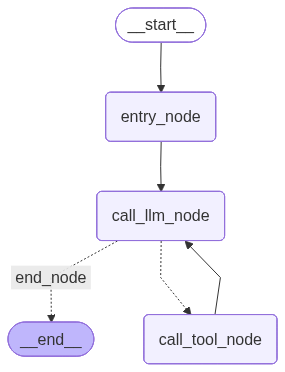

In [20]:
# Show the nodes and edges
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
# 6. Run the Graph
initial_state = {"query": "What is 5 plus 3 multiplied by 2?", "intermediate_steps": [], "result": None}

print("\nFinal State:")
res = app.invoke(initial_state)
res


Final State:
---ENTRY NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Last message is AIMessage with tool calls, routing to call_tool_node
---CALL TOOL NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Routing to end_node


{'query': 'What is 5 plus 3 multiplied by 2?',
 'intermediate_steps': [HumanMessage(content='What is 5 plus 3 multiplied by 2?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 79, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-Cd7KfKz0PPO7UPM7nsd1ftPcsekmi', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--36e27cc0-084e-4727-acb4-ebd2700f9d5a-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 3}, 'id': 'call_UxmzjfFrwXkFixCqVQv2Lw9g', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 3, 'b': 2}, 'id': 'call_Ctv

In [22]:
res['intermediate_steps'][-1].content

'5 plus 3 is 8, and 3 multiplied by 2 is 6.'

In [23]:
initial_state = {"query": "What is the sum of 12, 3, and 22?", "intermediate_steps": [], "result": None}

print("\nFinal State:")
res = app.invoke(initial_state)
res


Final State:
---ENTRY NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Last message is AIMessage with tool calls, routing to call_tool_node
---CALL TOOL NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Last message is AIMessage with tool calls, routing to call_tool_node
---CALL TOOL NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Routing to end_node


{'query': 'What is the sum of 12, 3, and 22?',
 'intermediate_steps': [HumanMessage(content='What is the sum of 12, 3, and 22?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 82, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-Cd7LMexyNwingRO3rfKAOCBcnaM84', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e9f1ecdf-647c-4e99-9dbc-5294bc08603d-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 3}, 'id': 'call_WtTBqPPH3FVndIXDARu0VNmi', 'type': 'tool_call'}], usage_metadata={'input_tokens': 82, 'output_tokens': 17, 'tot

In [24]:
res['intermediate_steps'][-1].content

'The sum of 12, 3, and 22 is 37.'

In [25]:
initial_state = {"query": "First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A and B. What is the final result?", "intermediate_steps": []}

print("\nFinal State:")
res = app.invoke(initial_state)
res


Final State:
---ENTRY NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Last message is AIMessage with tool calls, routing to call_tool_node
---CALL TOOL NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Last message is AIMessage with tool calls, routing to call_tool_node
---CALL TOOL NODE---
---CALL LLM NODE---
---DECIDE NEXT STEP NODE---
Routing to end_node


{'query': 'First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A and B. What is the final result?',
 'intermediate_steps': [HumanMessage(content='First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A and B. What is the final result?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 105, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-Cd7LtUgE6geJE0P1Oxjti9WUlzpsx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--525afe76-6a84-4a32-8fc0-db9a36619a03-0', tool_calls=[{'name

In [26]:
p80(initial_state['query'])
res['intermediate_steps'][-1].content

First, add 2 and 7, call it A. Then multiply 2 and 7, call it B. Finally, add A
and B. What is the final result?


'The final result is 23.'

## Using a State Graph

Reference: https://medium.com/@gitmaxd/understanding-state-in-langgraph-a-comprehensive-guide-191462220997#

The next blocks of code define a conversational workflow using the LangGraph library from the LangChain framework. Here's a breakdown of what the code does:

1. `add_messages` function:
   - This function takes two lists (`left` and `right`) and concatenates them, printing the result.
   - It is used as a custom merge function for the `messages` field in the `AgentState` TypedDict.

2. `AgentState` TypedDict:
   - This defines the state of the conversational agent, which includes a `messages` field that uses the `add_messages` function to merge updates.

3. `should_continue` function:
   - This function determines whether the conversation should continue or end.
   - It checks the last message in the `messages` list and if the message contains any `tool_calls`, it returns `"agent"`, indicating that the conversation should continue.
   - Otherwise, it returns `"__end__"`, indicating that the conversation should end.

4. `call_model` function:
   - This function is responsible for calling the language model and generating a response.
   - It takes the current state (`AgentState`) as input and returns a new state with the generated response added to the `messages` list.

5. `StateGraph` creation:
   - A `StateGraph` is created, which represents the conversational workflow.
   - The `AgentState` TypedDict is used as the state type for the graph.

6. Node and edge definitions:
   - The `"agent"` node is added, which calls the `call_model` function.
   - The `END` node is added, representing the end of the conversation.
   - The `"agent"` node is set as the entry point for the workflow.
   - A conditional edge is added from the `"agent"` node, using the `should_continue` function to determine the next node to call (either `"agent"` or `END`).

7. Compilation and output:
   - Finally, the `workflow` is compiled into a runnable `app`.
   - The nodes and edges of the compiled `workflow` are printed.

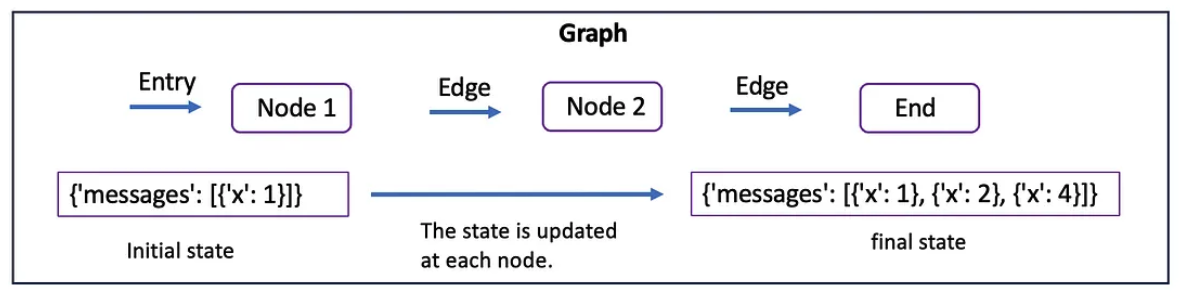

In [ ]:
Image("NLP_images/StateGraph.png", width=800)

## Will Agents make Humans Redundant?

Much has been written about humans being sidelined by AI agents. Yes, there are many realms where this is happening. However, there are certain areas where humans have resilient characteristics that are not easy to replace using AI. Here is an [article](https://www.understandingai.org/p/seven-big-advantages-human-workers) that proposes seven such characteristics:

1. Humans have physical bodies.
2. Humans are flexible and self-repairing.
3. Humans like to interact with other humans.
4. Humans care what other humans think.
5. Humans are scarce.
6. Humans are independent.
7. Humans form relationships with other humans.